In [1]:
import json
import os
import numpy as np
import matplotlib.pyplot as plt

In [2]:
import os
import re
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# =========================
# CONFIG
# =========================
ROOT = "output/phase_2/RadVLM"   # sửa nếu cần
DEFAULT_FILE = "radvlm_single_default.jsonl"

EMOTION_ORDER = [
    "neutral",
    "fear_anxiety",
    "anger_frustration",
    "sadness_distress",
]
ROLE_ORDER = ["patient", "clinician"]
EXPR_ORDER = ["direct", "indirect"]
MODE_ORDER = ["single", "multi"]

# =========================
# HELPERS
# =========================
def load_jsonl(path):
    rows = []
    with open(path, "r", encoding="utf-8") as f:
        for line in f:
            line = line.strip()
            if line:
                rows.append(json.loads(line))
    return rows

def safe_tuple(x):
    if x is None:
        return None
    return tuple(float(v) for v in x)

def make_key(row):
    """
    Key để match cùng 1 sample giữa các file.
    Dùng image + class_name + GT bbox.
    """
    return (
        row["image"],
        row.get("class_name", None),
        safe_tuple(row.get("bbox", None)),
    )

def bbox_iou(box1, box2):
    """
    box = [x1, y1, x2, y2], normalized hoặc absolute đều được miễn cùng hệ.
    """
    if box1 is None or box2 is None:
        return np.nan

    x1 = max(box1[0], box2[0])
    y1 = max(box1[1], box2[1])
    x2 = min(box1[2], box2[2])
    y2 = min(box1[3], box2[3])

    inter_w = max(0.0, x2 - x1)
    inter_h = max(0.0, y2 - y1)
    inter = inter_w * inter_h

    area1 = max(0.0, box1[2] - box1[0]) * max(0.0, box1[3] - box1[1])
    area2 = max(0.0, box2[2] - box2[0]) * max(0.0, box2[3] - box2[1])

    union = area1 + area2 - inter
    if union <= 0:
        return 0.0
    return inter / union

def best_iou_to_gt(gt_box, pred_boxes):
    """
    Nếu predicted_bboxes có nhiều box thì lấy box có IoU tốt nhất với GT.
    """
    if pred_boxes is None or len(pred_boxes) == 0:
        return np.nan, None

    ious = [bbox_iou(gt_box, pb) for pb in pred_boxes]
    best_idx = int(np.nanargmax(ious))
    return ious[best_idx], pred_boxes[best_idx]

def best_pairwise_iou(pred_boxes_a, pred_boxes_b):
    """
    Agreement giữa 2 output: lấy pair có IoU lớn nhất.
    """
    if pred_boxes_a is None or pred_boxes_b is None:
        return np.nan
    if len(pred_boxes_a) == 0 or len(pred_boxes_b) == 0:
        return np.nan

    best = -1
    for a in pred_boxes_a:
        for b in pred_boxes_b:
            best = max(best, bbox_iou(a, b))
    return best if best >= 0 else np.nan

def parse_filename(fname):
    """
    Parse tên file:
    - radvlm_single_default.jsonl
    - radvlm_multi_direct_clinician_neutral.jsonl
    """
    stem = fname.replace(".jsonl", "")

    if stem == "radvlm_single_default":
        return {
            "mode": "single",
            "expression": "default",
            "role": "default",
            "emotion": "default",
            "setting": "default",
        }

    m = re.match(
        r"radvlm_(single|multi)_(direct|indirect)_(clinician|patient)_(neutral|sadness_distress|anger_frustration|fear_anxiety)$",
        stem
    )
    if not m:
        return None

    mode, expression, role, emotion = m.groups()
    return {
        "mode": mode,
        "expression": expression,
        "role": role,
        "emotion": emotion,
        "setting": f"{mode}_{expression}_{role}_{emotion}",
    }

# =========================
# LOAD DEFAULT
# =========================
default_path = os.path.join(ROOT, DEFAULT_FILE)
default_rows = load_jsonl(default_path)

default_map = {}
for row in default_rows:
    key = make_key(row)
    default_map[key] = row

print(f"Loaded default: {len(default_map)} samples")

# =========================
# LOAD ALL FILES + COMPUTE
# =========================
all_records = []

for fname in sorted(os.listdir(ROOT)):
    if not fname.endswith(".jsonl"):
        continue

    meta = parse_filename(fname)
    if meta is None:
        print(f"Skip unrecognized file: {fname}")
        continue

    path = os.path.join(ROOT, fname)
    rows = load_jsonl(path)

    for row in rows:
        key = make_key(row)

        gt_box = row.get("bbox", None)
        pred_boxes = row.get("predicted_bboxes", [])

        perf_iou, best_pred = best_iou_to_gt(gt_box, pred_boxes)

        default_row = default_map.get(key, None)
        if default_row is not None:
            default_pred_boxes = default_row.get("predicted_bboxes", [])
            agreement_iou = best_pairwise_iou(pred_boxes, default_pred_boxes)

            default_perf_iou, default_best_pred = best_iou_to_gt(
                default_row.get("bbox", None),
                default_pred_boxes
            )
        else:
            agreement_iou = np.nan
            default_perf_iou = np.nan
            default_best_pred = None

        all_records.append({
            "file": fname,
            "image": row["image"],
            "class_name": row.get("class_name", None),
            "gt_bbox": row.get("bbox", None),
            "predicted_bboxes": pred_boxes,
            "best_pred_bbox": best_pred,
            "perf_iou": perf_iou,
            "agreement_iou": agreement_iou,
            "default_best_pred_bbox": default_best_pred,
            "default_perf_iou": default_perf_iou,
            **meta
        })

df = pd.DataFrame(all_records)

print(df.shape)
display(df.head())

Loaded default: 2697 samples
(89001, 15)


,file,image,class_name,gt_bbox,predicted_bboxes,best_pred_bbox,perf_iou,agreement_iou,default_best_pred_bbox,default_perf_iou,mode,expression,role,emotion,setting
0,radvlm_multi_direct_clinician_anger_frustratio...,vindr_test/processed/e0dc2e79105ad93532484e956...,Calcification,"[0.57, 0.27, 0.63, 0.32]","[[0.56, 0.25, 0.62, 0.34]]","[0.56, 0.25, 0.62, 0.34]",0.423729,1.000000,"[0.56, 0.25, 0.62, 0.34]",0.423729,multi,direct,clinician,anger_frustration,multi_direct_clinician_anger_frustration
1,radvlm_multi_direct_clinician_anger_frustratio...,vindr_test/processed/e0dc2e79105ad93532484e956...,Cardiomegaly,"[0.3, 0.54, 0.84, 0.8]","[[0.33, 0.49, 0.84, 0.83]]","[0.33, 0.49, 0.84, 0.83]",0.731788,1.000000,"[0.33, 0.49, 0.84, 0.83]",0.731788,multi,direct,clinician,anger_frustration,multi_direct_clinician_anger_frustration
2,radvlm_multi_direct_clinician_anger_frustratio...,vindr_test/processed/e0dc2e79105ad93532484e956...,ILD,"[0.79, 0.58, 0.9, 0.8]","[[0.14, 0.14, 0.44, 0.68], [0.6, 0.46, 0.91, 0...","[0.6, 0.46, 0.91, 0.85]",0.200165,0.780723,"[0.64, 0.49, 0.92, 0.85]",0.240079,multi,direct,clinician,anger_frustration,multi_direct_clinician_anger_frustration
3,radvlm_multi_direct_clinician_anger_frustratio...,vindr_test/processed/e0dc2e79105ad93532484e956...,Pneumothorax,"[0.19, 0.06, 0.47, 0.21]","[[0.12, 0.06, 0.46, 0.34]]","[0.12, 0.06, 0.46, 0.34]",0.418821,1.000000,"[0.12, 0.06, 0.46, 0.34]",0.418821,multi,direct,clinician,anger_frustration,multi_direct_clinician_anger_frustration
4,radvlm_multi_direct_clinician_anger_frustratio...,vindr_test/processed/e0dc2e79105ad93532484e956...,Pneumothorax,"[0.16, 0.2, 0.21, 0.31]","[[0.12, 0.06, 0.46, 0.34]]","[0.12, 0.06, 0.46, 0.34]",0.057773,1.000000,"[0.12, 0.06, 0.46, 0.34]",0.057773,multi,direct,clinician,anger_frustration,multi_direct_clinician_anger_frustration


In [3]:
def mean_std_str(x):
    x = pd.Series(x).dropna()
    if len(x) == 0:
        return "nan"
    return f"{x.mean():.3f} ± {x.std():.3f}"

summary = (
    df.groupby(["mode", "expression", "role", "emotion"], dropna=False)
      .agg(
          n=("perf_iou", "size"),
          perf_iou_mean=("perf_iou", "mean"),
          perf_iou_std=("perf_iou", "std"),
          agreement_iou_mean=("agreement_iou", "mean"),
          agreement_iou_std=("agreement_iou", "std"),
      )
      .reset_index()
)

display(summary.sort_values(["mode", "expression", "role", "emotion"]))

,mode,expression,role,emotion,n,perf_iou_mean,perf_iou_std,agreement_iou_mean,agreement_iou_std
0,multi,direct,clinician,anger_frustration,2697,0.319947,0.285370,0.914167,0.183891
1,multi,direct,clinician,fear_anxiety,2697,0.319384,0.284632,0.912892,0.185758
2,multi,direct,clinician,neutral,2697,0.320675,0.285114,0.927220,0.169956
3,multi,direct,clinician,sadness_distress,2697,0.320399,0.285077,0.913882,0.187086
4,multi,direct,patient,anger_frustration,2697,0.320615,0.284942,0.919113,0.179081
5,multi,direct,patient,fear_anxiety,2697,0.320089,0.284794,0.917349,0.181781
6,multi,direct,patient,neutral,2697,0.320248,0.285087,0.927103,0.170979
7,multi,direct,patient,sadness_distress,2697,0.320316,0.284932,0.916608,0.183607
8,multi,indirect,clinician,anger_frustration,2697,0.321563,0.285462,0.869344,0.222596
9,multi,indirect,clinician,fear_anxiety,2697,0.321301,0.284198,0.869678,0.215624


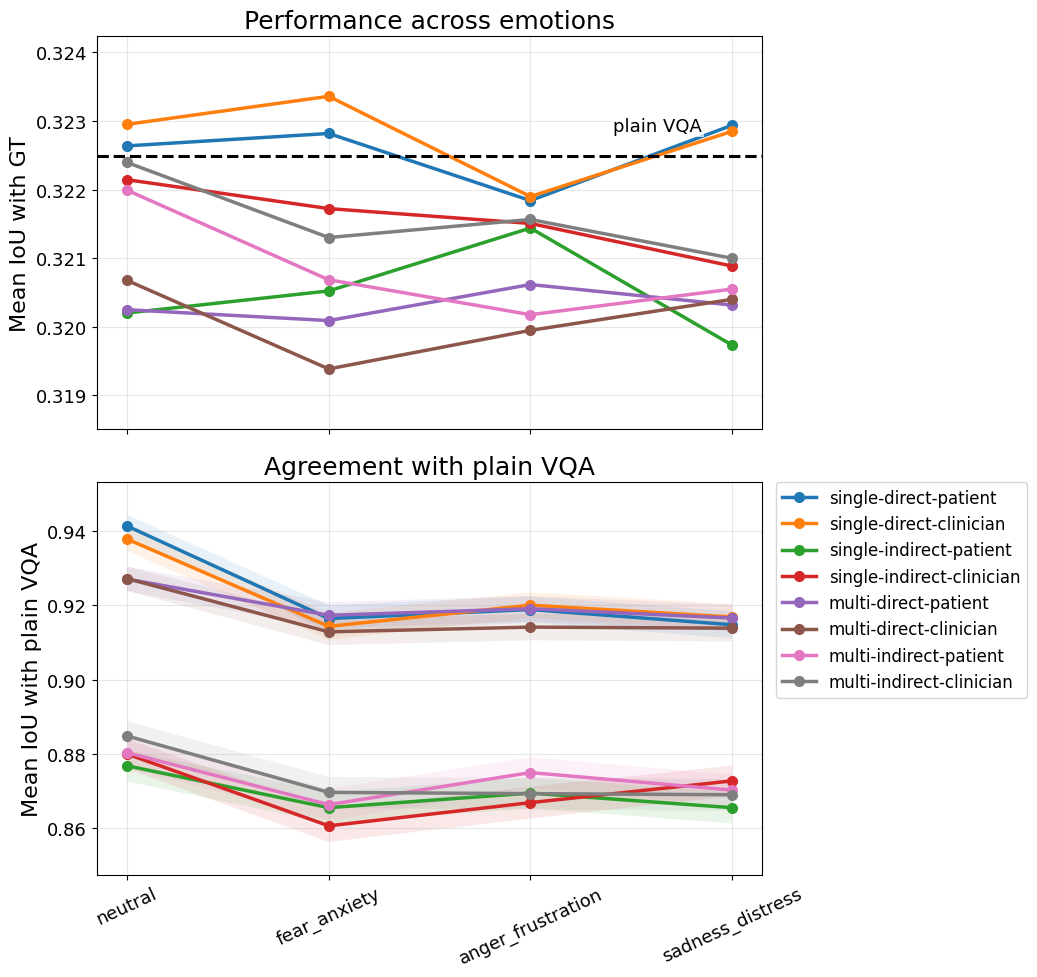

In [17]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

plt.rcParams.update({
    "font.size": 14,
    "axes.titlesize": 18,
    "axes.labelsize": 16,
    "xtick.labelsize": 13,
    "ytick.labelsize": 13,
    "legend.fontsize": 12,
})

# -----------------------------
# summary for emotion settings
# -----------------------------
emotion_summary = (
    df[df["emotion"] != "default"]
    .groupby(["mode", "expression", "role", "emotion"], dropna=False)
    .agg(
        perf_iou_mean=("perf_iou", "mean"),
        perf_iou_std=("perf_iou", "std"),
        perf_iou_n=("perf_iou", "count"),
        agreement_iou_mean=("agreement_iou", "mean"),
        agreement_iou_std=("agreement_iou", "std"),
        agreement_iou_n=("agreement_iou", "count"),
    )
    .reset_index()
)

emotion_summary["group"] = emotion_summary.apply(
    lambda r: f"{r['mode']}-{r['expression']}-{r['role']}",
    axis=1
)

group_order = [
    f"{m}-{e}-{r}"
    for m in MODE_ORDER
    for e in EXPR_ORDER
    for r in ROLE_ORDER
]

# -----------------------------
# default / plain VQA baseline
# -----------------------------
default_df = df[df["emotion"] == "default"].copy()
default_perf_mean = default_df["perf_iou"].mean()

x = np.arange(len(EMOTION_ORDER))

fig, axes = plt.subplots(2, 1, figsize=(13, 10), sharex=True)

all_perf_vals = [default_perf_mean]
all_agree_low, all_agree_high = [], []

for g in group_order:
    sub = emotion_summary[emotion_summary["group"] == g].copy()
    if len(sub) == 0:
        continue

    sub["emotion"] = pd.Categorical(
        sub["emotion"], categories=EMOTION_ORDER, ordered=True
    )
    sub = sub.sort_values("emotion")

    perf_mean = sub["perf_iou_mean"].to_numpy()

    agree_mean = sub["agreement_iou_mean"].to_numpy()
    agree_std  = sub["agreement_iou_std"].fillna(0).to_numpy()
    agree_n    = sub["agreement_iou_n"].to_numpy()
    agree_sem  = agree_std / np.sqrt(np.maximum(agree_n, 1))
    agree_band = agree_sem

    agree_low  = agree_mean - agree_band
    agree_high = agree_mean + agree_band

    all_perf_vals.extend(perf_mean.tolist())
    all_agree_low.extend(agree_low.tolist())
    all_agree_high.extend(agree_high.tolist())

    axes[0].plot(x, perf_mean, marker="o", linewidth=2.5, markersize=7, label=g)
    axes[1].plot(x, agree_mean, marker="o", linewidth=2.5, markersize=7, label=g)
    axes[1].fill_between(x, agree_low, agree_high, alpha=0.10)

# plain VQA horizontal baseline on top plot
axes[0].axhline(
    y=default_perf_mean,
    linestyle="--",
    linewidth=2.2,
    color="black"
)

# inline text label for plain VQA
axes[0].text(
    x[-1] - 0.15,
    default_perf_mean + 0.0003,
    "plain VQA",
    color="black",
    fontsize=13,
    ha="right",
    va="bottom",
    bbox=dict(facecolor="white", edgecolor="none", alpha=0.7, pad=1.5)
)

def smart_ylim_from_vals(vals, pad_ratio=0.18):
    vals = np.array(vals, dtype=float)
    y_min = np.nanmin(vals)
    y_max = np.nanmax(vals)
    pad = (y_max - y_min) * pad_ratio if y_max > y_min else 0.002
    return y_min - pad, y_max + pad

def smart_ylim_from_band(lows, highs, pad_ratio=0.08):
    lows = np.array(lows, dtype=float)
    highs = np.array(highs, dtype=float)
    y_min = np.nanmin(lows)
    y_max = np.nanmax(highs)
    pad = (y_max - y_min) * pad_ratio if y_max > y_min else 0.002
    return y_min - pad, y_max + pad

perf_ymin, perf_ymax = smart_ylim_from_vals(all_perf_vals, pad_ratio=0.22)
agree_ymin, agree_ymax = smart_ylim_from_band(all_agree_low, all_agree_high, pad_ratio=0.10)

axes[0].set_title("Performance across emotions")
axes[0].set_ylabel("Mean IoU with GT")
axes[0].grid(alpha=0.3)
axes[0].set_ylim(perf_ymin, perf_ymax)

axes[1].set_title("Agreement with plain VQA")
axes[1].set_ylabel("Mean IoU with plain VQA")
axes[1].grid(alpha=0.3)
axes[1].set_ylim(agree_ymin, agree_ymax)

axes[1].set_xticks(x)
axes[1].set_xticklabels(EMOTION_ORDER, rotation=25)

axes[1].legend(
    bbox_to_anchor=(1.02, 1),
    loc="upper left",
    borderaxespad=0.0,
    frameon=True
)

plt.tight_layout(rect=[0, 0, 0.82, 1])
plt.show()

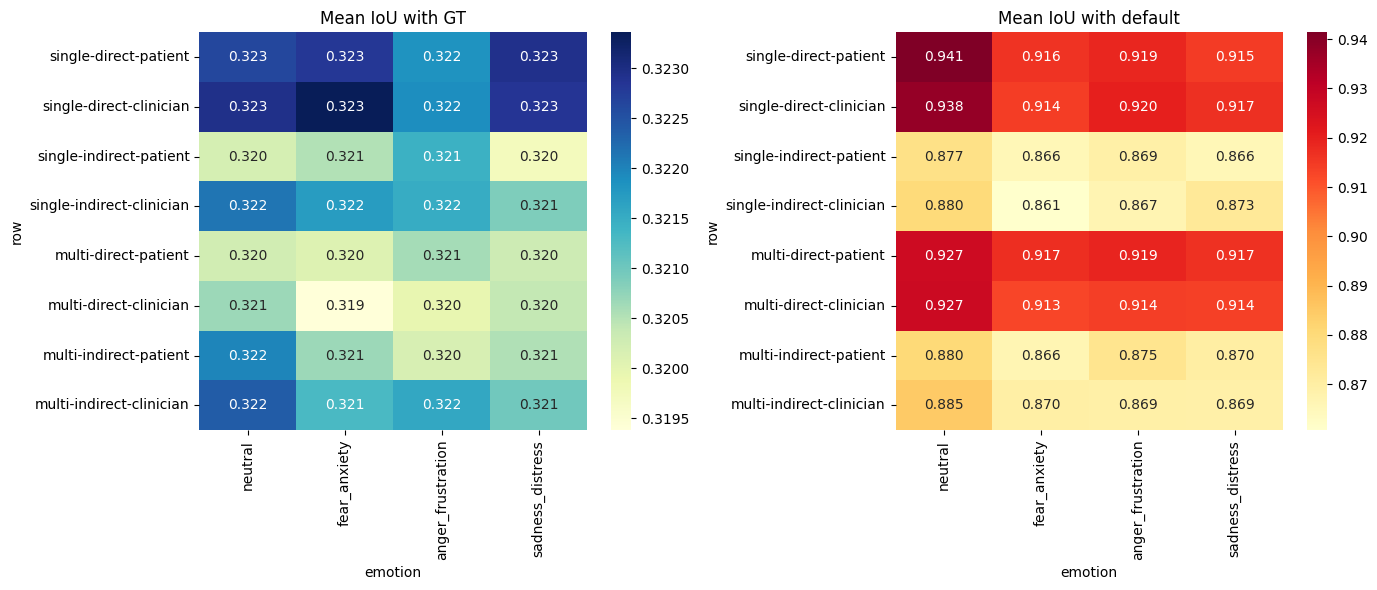

In [6]:
import seaborn as sns

heat_perf = (
    df[df["emotion"] != "default"]
    .groupby(["mode", "expression", "role", "emotion"])["perf_iou"]
    .mean()
    .reset_index()
)
heat_perf["row"] = heat_perf.apply(lambda r: f"{r['mode']}-{r['expression']}-{r['role']}", axis=1)
heat_perf = heat_perf.pivot(index="row", columns="emotion", values="perf_iou")
heat_perf = heat_perf.reindex(index=group_order, columns=EMOTION_ORDER)

heat_agree = (
    df[df["emotion"] != "default"]
    .groupby(["mode", "expression", "role", "emotion"])["agreement_iou"]
    .mean()
    .reset_index()
)
heat_agree["row"] = heat_agree.apply(lambda r: f"{r['mode']}-{r['expression']}-{r['role']}", axis=1)
heat_agree = heat_agree.pivot(index="row", columns="emotion", values="agreement_iou")
heat_agree = heat_agree.reindex(index=group_order, columns=EMOTION_ORDER)

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

sns.heatmap(heat_perf, annot=True, fmt=".3f", cmap="YlGnBu", ax=axes[0])
axes[0].set_title("Mean IoU with GT")

sns.heatmap(heat_agree, annot=True, fmt=".3f", cmap="YlOrRd", ax=axes[1])
axes[1].set_title("Mean IoU with default")

plt.tight_layout()
plt.show()

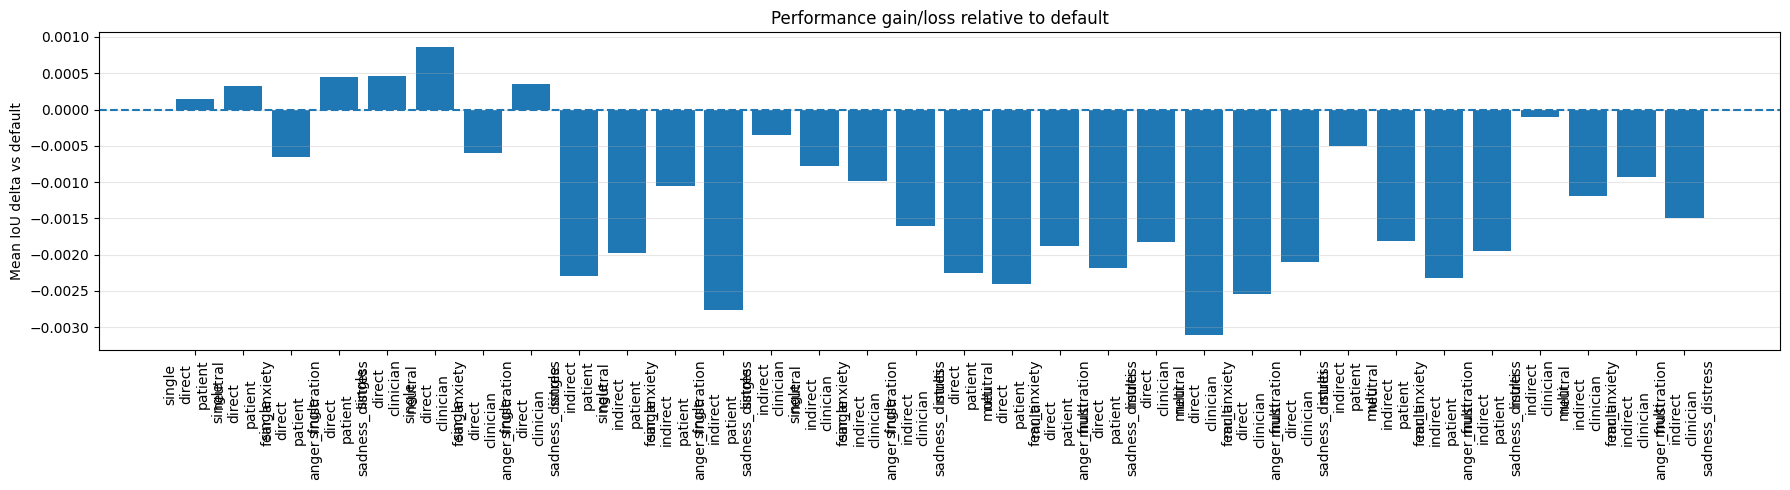

In [8]:
# Chỉ giữ non-default
cmp_df = df[df["emotion"] != "default"].copy()

cmp_summary = (
    cmp_df.groupby(["mode", "expression", "role", "emotion"])
    .agg(
        perf_iou_mean=("perf_iou", "mean"),
        default_perf_iou_mean=("default_perf_iou", "mean"),
        agreement_iou_mean=("agreement_iou", "mean"),
    )
    .reset_index()
)

cmp_summary["delta_vs_default"] = (
    cmp_summary["perf_iou_mean"] - cmp_summary["default_perf_iou_mean"]
)

cmp_plot = cmp_summary.copy()
cmp_plot["label"] = cmp_plot.apply(
    lambda r: f"{r['mode']}\n{r['expression']}\n{r['role']}\n{r['emotion']}",
    axis=1
)

cmp_plot = cmp_plot.sort_values(
    ["mode", "expression", "role", "emotion"],
    key=lambda col: col.map(
        {
            **{k: i for i, k in enumerate(MODE_ORDER)},
            **{k: i for i, k in enumerate(EXPR_ORDER)},
            **{k: i for i, k in enumerate(ROLE_ORDER)},
            **{k: i for i, k in enumerate(EMOTION_ORDER)},
        }
    ) if col.name in ["mode", "expression", "role", "emotion"] else col
)

plt.figure(figsize=(18, 5))
plt.bar(np.arange(len(cmp_plot)), cmp_plot["delta_vs_default"])
plt.axhline(0, linestyle="--")
plt.xticks(np.arange(len(cmp_plot)), cmp_plot["label"], rotation=90)
plt.ylabel("Mean IoU delta vs default")
plt.title("Performance gain/loss relative to default")
plt.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.show()